1) Notebook completo para Google Colab

1.1 Instalación y descarga

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import time

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = pd.read_csv("PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


1.2 Carga + limpieza mínima

In [ ]:
df.columns = [c.strip() for c in df.columns]

# Check if 'Datetime' is already the index and reset if needed
if df.index.name == 'Datetime':
    df = df.reset_index()

# Ensure 'Datetime' column exists before proceeding
if 'Datetime' not in df.columns:
    raise KeyError("The 'Datetime' column is missing from the DataFrame. Please check the previous steps.")

df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")
# Eliminar duplicados antes de establecer el índice para evitar el error
df = df.drop_duplicates(subset=['Datetime'])
df = df.set_index("Datetime")

df = df.asfreq("H")  # frecuencia horaria
df = df.interpolate()  # relleno suave si hubiera huecos

target_col = df.columns[0]  # PJME_MW
df.rename(columns={target_col: "y"}, inplace=True)

df.head(), df.index.min(), df.index.max(), df.shape

(                           y
 Datetime                    
 2002-01-01 01:00:00  30393.0
 2002-01-01 02:00:00  29265.0
 2002-01-01 03:00:00  28357.0
 2002-01-01 04:00:00  27899.0
 2002-01-01 05:00:00  28057.0,
 Timestamp('2002-01-01 01:00:00'),
 Timestamp('2018-08-03 00:00:00'),
 (145392, 1))

1.3 Exploración

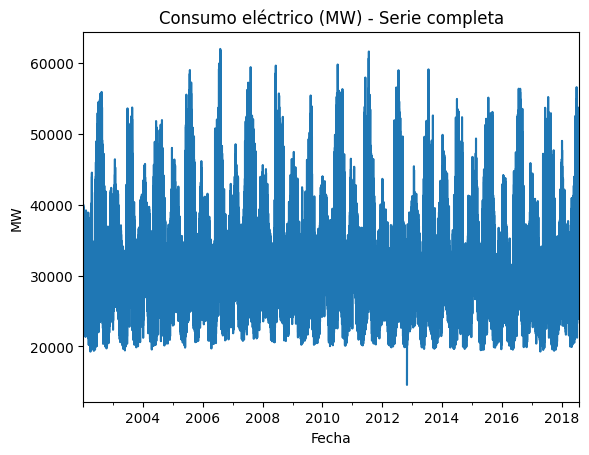

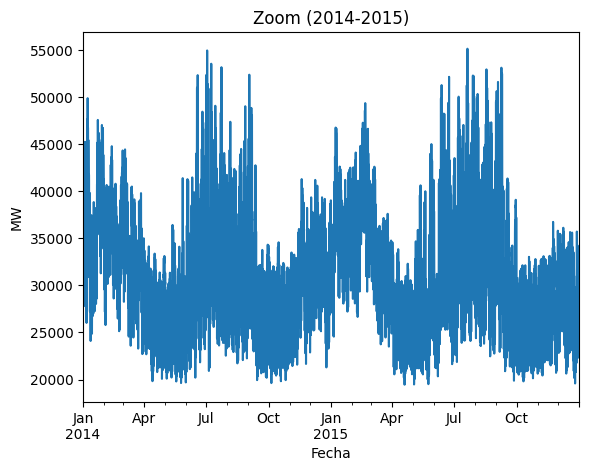

In [ ]:
plt.figure()
df["y"].plot()
plt.title("Consumo eléctrico (MW) - Serie completa")
plt.xlabel("Fecha")
plt.ylabel("MW")
plt.show()

plt.figure()
df["y"].loc["2014":"2015"].plot()
plt.title("Zoom (2014-2015)")
plt.xlabel("Fecha")
plt.ylabel("MW")
plt.show()

1.4 Split temporal Train/Test

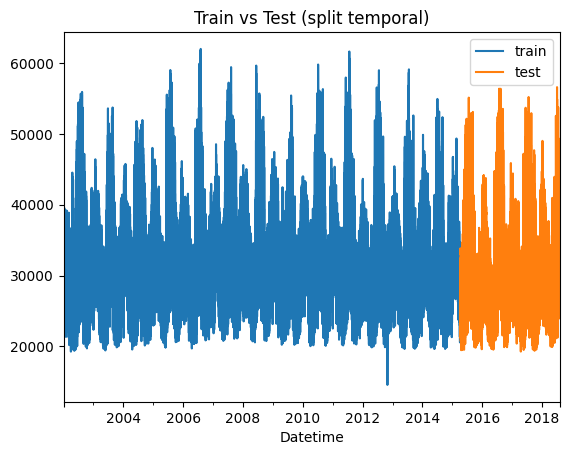

(116313, 29079)

In [ ]:
n = len(df)
split = int(n * 0.8)
train = df.iloc[:split].copy()
test  = df.iloc[split:].copy()

plt.figure()
train["y"].plot(label="train")
test["y"].plot(label="test")
plt.title("Train vs Test (split temporal)")
plt.legend()
plt.show()

len(train), len(test)

2) Modelos de Machine Learning

2.1 Features: calendario + lags

In [ ]:
def make_features(data: pd.DataFrame, lags=(1, 24, 168)):
    X = pd.DataFrame(index=data.index)
    # Calendario
    X["hour"] = data.index.hour
    X["dayofweek"] = data.index.dayofweek
    X["month"] = data.index.month
    X["dayofyear"] = data.index.dayofyear
    X["is_weekend"] = (data.index.dayofweek >= 5).astype(int)

    # Lags
    for L in lags:
        X[f"lag_{L}"] = data["y"].shift(L)

    # Rolling stats (opcionales, suman calidad)
    X["roll_mean_24"] = data["y"].shift(1).rolling(24).mean()
    X["roll_std_24"]  = data["y"].shift(1).rolling(24).std()

    y = data["y"].copy()
    out = X.join(y).dropna()
    return out.drop(columns=["y"]), out["y"]

X_train, y_train = make_features(train)
X_test, y_test   = make_features(pd.concat([train.tail(200), test]))  # margen para lags
# quedarnos solo con el periodo del test
X_test = X_test.loc[test.index.intersection(X_test.index)]
y_test = y_test.loc[X_test.index]

X_train.shape, X_test.shape

((116145, 10), (29079, 10))

2.2 Funciones de evaluación (métrica + tiempo)

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(name, fit_fn, pred_fn):
    t0 = time.time()
    model = fit_fn()
    train_time = time.time() - t0

    y_pred = pred_fn(model)
    return {
        "model": name,
        "RMSE": rmse(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "train_seconds": train_time,
        "y_pred": y_pred
    }

2.3 Modelos

Regresión Lineal (ML1)

In [ ]:
from sklearn.linear_model import LinearRegression

res_lin = evaluate_model(
    "LinearRegression (ML1)",
    fit_fn=lambda: LinearRegression().fit(X_train, y_train),
    pred_fn=lambda m: m.predict(X_test)
)
res_lin["RMSE"], res_lin["MAE"]

(1253.7219268692106, 976.4659276972887)

KNN Regressor (ML1 alternativo)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

res_knn = evaluate_model(
    "KNNRegressor (ML1)",
    fit_fn=lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=10))
    ]).fit(X_train, y_train),
    pred_fn=lambda m: m.predict(X_test)
)
res_knn["RMSE"], res_knn["MAE"]

(1050.7746579738557, 807.8226985109529)

Árboles (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

res_rf = evaluate_model(
    "RandomForestRegressor (Trees)",
    fit_fn=lambda: RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1, max_depth=None
    ).fit(X_train, y_train),
    pred_fn=lambda m: m.predict(X_test)
)
res_rf["RMSE"], res_rf["MAE"]

(415.17386548029395, 299.6566229925376)

SVM (SVR)

In [ ]:
from sklearn.svm import SVR

# Para que no explote en tiempo, entrenamos con una muestra reciente (ej: últimos 60 días)
recent_days = 60
X_train_svr = X_train.loc[X_train.index >= (X_train.index.max() - pd.Timedelta(days=recent_days))]
y_train_svr = y_train.loc[X_train_svr.index]

res_svr = evaluate_model(
    "SVR (SVM)",
    fit_fn=lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=10, epsilon=0.1, kernel="rbf"))
    ]).fit(X_train_svr, y_train_svr),
    pred_fn=lambda m: m.predict(X_test)
)
res_svr["RMSE"], res_svr["MAE"]

(6595.191664203955, 5358.718507692959)

3) Modelo de series de tiempo (ARIMA)

3.1 ARIMA básico

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA sobre la serie (sin features)
# Nota: elegir (p,d,q) simple para el TP. Ejemplo: (2,1,2)
order = (2, 1, 2)

t0 = time.time()
arima = ARIMA(train["y"], order=order).fit()
train_time_arima = time.time() - t0

# forecast en el horizonte del test
y_pred_arima = arima.forecast(steps=len(test))
y_pred_arima.index = test.index  # alinear índice

res_arima = {
    "model": f"ARIMA{order}",
    "RMSE": rmse(test["y"], y_pred_arima),
    "MAE": mean_absolute_error(test["y"], y_pred_arima),
    "train_seconds": train_time_arima,
    "y_pred": y_pred_arima.values
}
res_arima["RMSE"], res_arima["MAE"]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(6944.081679091017, 5095.929289933559)

4) Tabla final + gráficos comparativos

4.1 Tabla de resultados

In [ ]:
results = [res_lin, res_knn, res_rf, res_svr, res_arima]

table = pd.DataFrame([{
    "Modelo": r["model"],
    "RMSE": r["RMSE"],
    "MAE": r["MAE"],
    "Tiempo entrenamiento (s)": r["train_seconds"]
} for r in results]).sort_values("RMSE")

table

,Modelo,RMSE,MAE,Tiempo entrenamiento (s)
2,RandomForestRegressor (Trees),415.173865,299.656623,235.902811
1,KNNRegressor (ML1),1050.774658,807.822699,0.291069
0,LinearRegression (ML1),1253.721927,976.465928,0.038095
3,SVR (SVM),6595.191664,5358.718508,0.282436
4,"ARIMA(2, 1, 2)",6944.081679,5095.929290,53.742832


4.2 Gráfico: RMSE por modelo

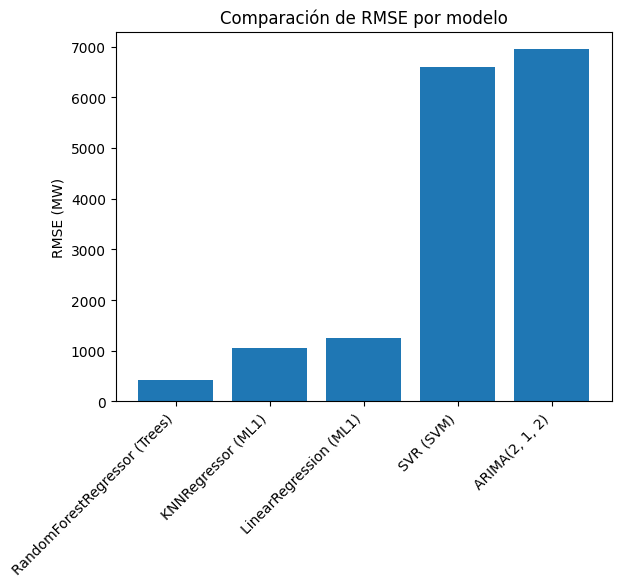

In [ ]:
plt.figure()
plt.bar(table["Modelo"], table["RMSE"])
plt.title("Comparación de RMSE por modelo")
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE (MW)")
plt.show()

4.3 Gráfico: tiempo de entrenamiento por modelo

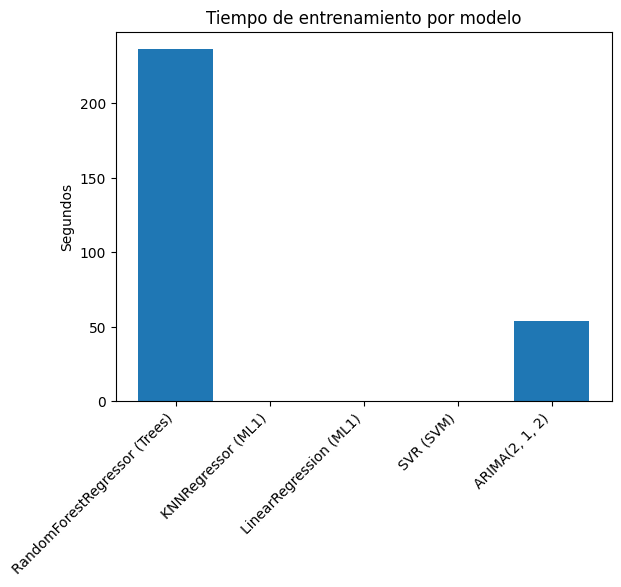

In [ ]:
plt.figure()
plt.bar(table["Modelo"], table["Tiempo entrenamiento (s)"])
plt.title("Tiempo de entrenamiento por modelo")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Segundos")
plt.show()

4.4 Forecast vs Real (para 2 mejores modelos)

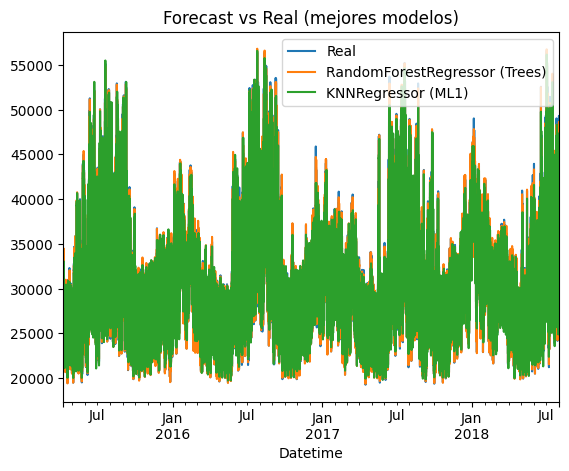

In [ ]:
# Tomamos los 2 mejores por RMSE
best_models = table["Modelo"].head(2).tolist()

pred_map = {r["model"]: r["y_pred"] for r in results}
# Ojo: ARIMA pred_map viene como np.array, pero con mismo orden que test
y_true_plot = test["y"].loc[X_test.index] if len(X_test.index)==len(y_test) else test["y"]

plt.figure()
y_true_plot.plot(label="Real")

for m in best_models:
    yhat = pred_map[m]
    # si no tiene index, lo alineamos al index de y_test
    if not isinstance(yhat, pd.Series):
        yhat = pd.Series(yhat, index=y_test.index)
    else:
        yhat = yhat.loc[y_test.index]
    yhat.plot(label=m)

plt.title("Forecast vs Real (mejores modelos)")
plt.legend()
plt.show()